In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('placement.csv')

In [31]:
df.sample(5)

,cgpa,placement_exam_marks,placed
443,6.92,77.0,0
709,6.97,42.0,1
474,7.11,25.0,1
394,7.94,18.0,1
548,7.48,30.0,1


In [32]:
df.shape

(1000, 3)

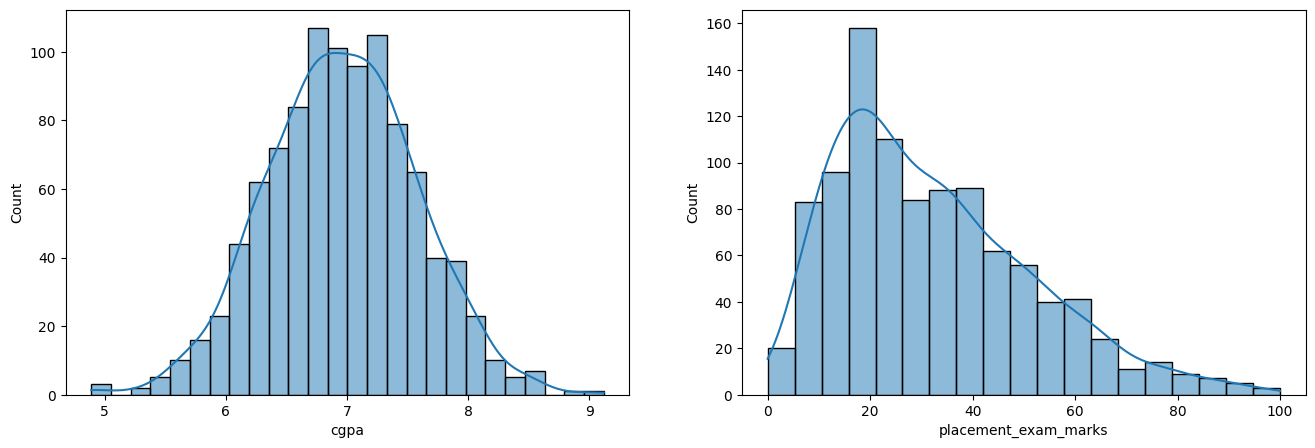

In [33]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True)

plt.show()

## Observation:
Upon observing the data, it becomes evident that the **cgpa** column follows a normal distribution, while the **placement_exam_marks** column exhibits right-skewness. Since z-score approach is applicable only to the normal distribution, so we apply it to **cgpa** column.

In [34]:
print('The min value in CGPA column', df['cgpa'].min())
print('The max value in CGPA column', df['cgpa'].max())
print('The max value in CGPA column', df['cgpa'].mean())
print('The max value in CGPA column', df['cgpa'].std())

The min value in CGPA column 4.89
The max value in CGPA column 9.12
The max value in CGPA column 6.96124
The max value in CGPA column 0.6158978751323896


In [35]:
#finding boundary value
upper_limit=df['cgpa'].mean() + 3*df['cgpa'].std()
lowest_limit=df['cgpa'].mean() - 3*df['cgpa'].std()
print('highest boundary :',upper_limit)
print('lowest boundary :', lowest_limit)

highest boundary : 8.808933625397168
lowest boundary : 5.113546374602832


In [36]:
# Finding the outliers

df[(df['cgpa'] > upper_limit) | (df['cgpa'] <lowest_limit)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


We see that there are 3 rows with values below the lower boundary and 2 rows with values above the highest boundary with total=5 rows

To address the outliers, we will employ the trimming approach and eliminate all rows with outliers in our dataset.

# Approach 1.1) Trimming without using z-score

In [41]:
new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]

print(f"shape:{new_df.shape}") # rows,columns
print("###############")
print(f"new_df:\n{new_df}")

shape:(995, 3)
###############
new_df:
     cgpa  placement_exam_marks  placed
0    7.19                  26.0       1
1    7.46                  38.0       1
2    7.54                  40.0       1
3    6.42                   8.0       1
4    7.23                  17.0       0
..    ...                   ...     ...
991  7.04                  57.0       0
992  6.26                  12.0       0
993  6.73                  21.0       1
994  6.48                  63.0       0
998  8.62                  46.0       1

[995 rows x 3 columns]


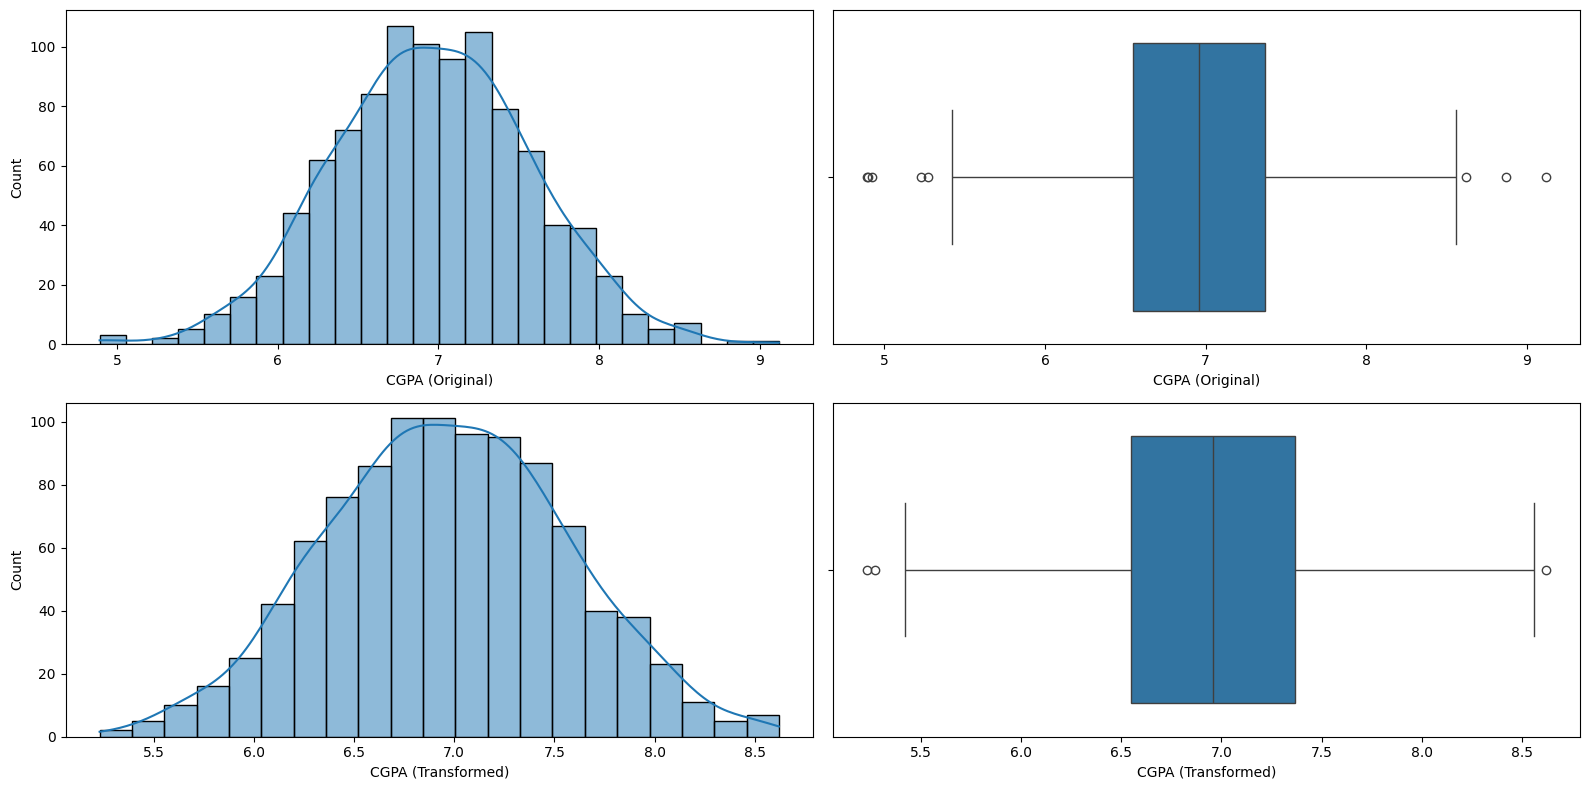

In [39]:
plt.figure(figsize=(16, 8))

# First subplot
plt.subplot(2, 2, 1)
sns.histplot(df['cgpa'], kde=True)  
plt.xlabel("CGPA (Original)")  

# Second subplot
plt.subplot(2, 2, 2)
sns.boxplot(x=df['cgpa'])
plt.xlabel("CGPA (Original)")

# Third subplot
plt.subplot(2, 2, 3)
sns.histplot(new_df['cgpa'], kde=True)
plt.xlabel("CGPA (Transformed)")

# Fourth subplot
plt.subplot(2, 2, 4)
sns.boxplot(x=new_df['cgpa'])
plt.xlabel("CGPA (Transformed)")

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

### Great. Plot is relatively same

# Approach 1.2) Trimming using z-score

In [43]:
# Calculate the Zscore

df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [44]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


### We get the same result as above previous approach. No surprises here. Both lead to same result.
Now we trim.

In [45]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

print(f"shape:{new_df.shape}") # rows,columns
print("###############")
print(f"new_df:\n{new_df}")

shape:(995, 4)
###############
new_df:
     cgpa  placement_exam_marks  placed  cgpa_zscore
0    7.19                  26.0       1     0.371425
1    7.46                  38.0       1     0.809810
2    7.54                  40.0       1     0.939701
3    6.42                   8.0       1    -0.878782
4    7.23                  17.0       0     0.436371
..    ...                   ...     ...          ...
991  7.04                  57.0       0     0.127878
992  6.26                  12.0       0    -1.138565
993  6.73                  21.0       1    -0.375452
994  6.48                  63.0       0    -0.781363
998  8.62                  46.0       1     2.693239

[995 rows x 4 columns]


# Approach 2) Capping

Let’s apply the capping method to address the outliers in the dataset.

To handle outliers using the capping method, we will **replace** all values above the upper limit with the upper limit value and all values below the lower limit with the lower limit value.

In [21]:
cap_df=df.copy()
cap_df['cgpa'] = np.where(
    cap_df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        cap_df['cgpa']<lowest_limit,
        lowest_limit,
        cap_df['cgpa']
    )
)

In [22]:
cap_df.shape

(1000, 4)

We observed that the shape of the dataset remains unchanged after implementing the capping method. No surprises here

In [23]:
print('The min value in CGPA column', cap_df['cgpa'].min())
print('The max value in CGPA column', cap_df['cgpa'].max())

The min value in CGPA column 5.113546374602832
The max value in CGPA column 8.808933625397168


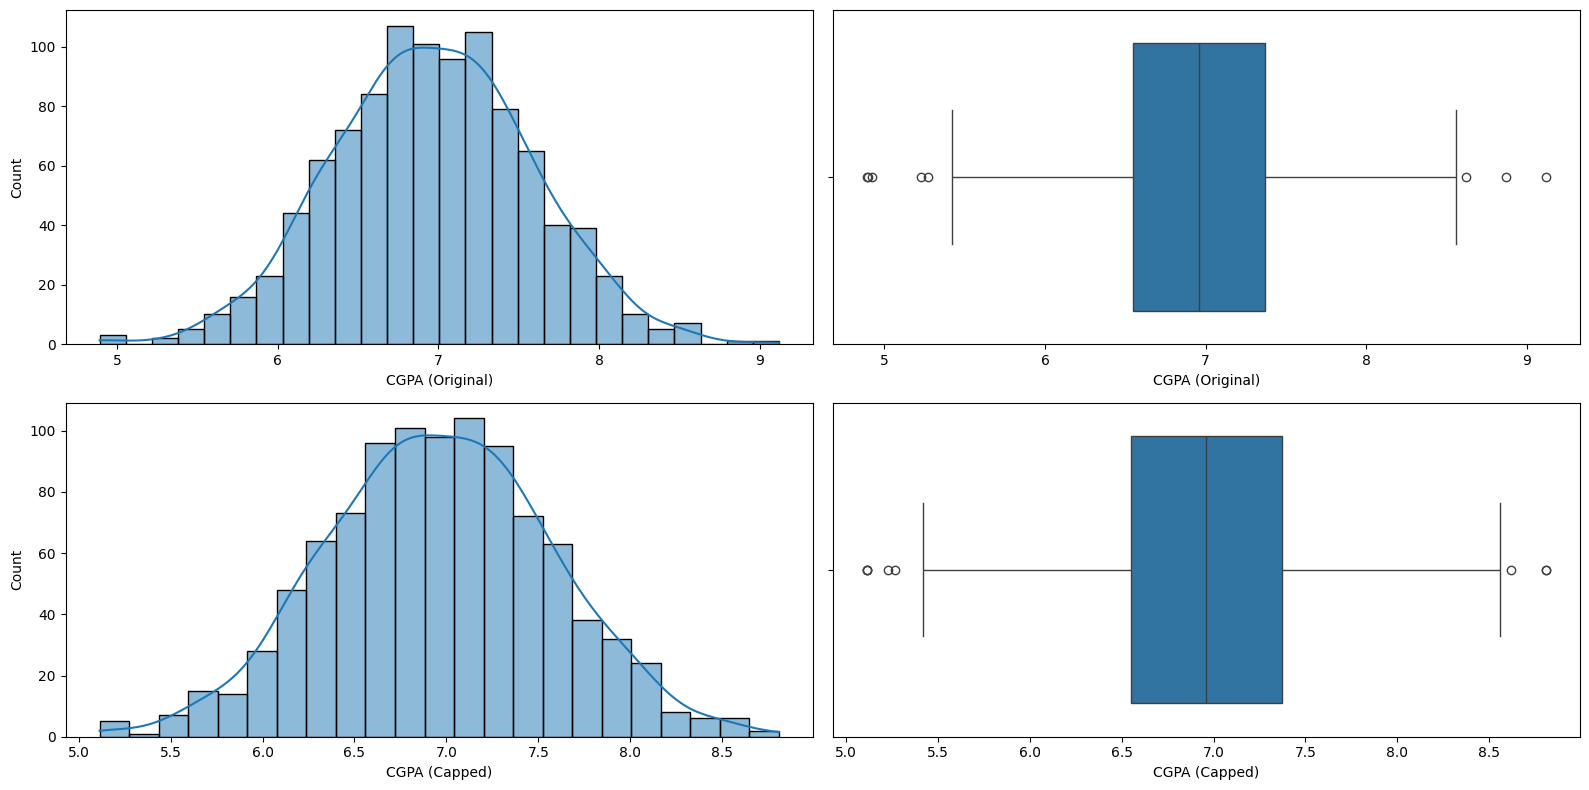

In [46]:
plt.figure(figsize=(16, 8))

# First subplot
plt.subplot(2, 2, 1)
sns.histplot(df['cgpa'], kde=True)  # Use histplot instead of distplot
plt.xlabel("CGPA (Original)")

# Second subplot
plt.subplot(2, 2, 2)
sns.boxplot(x=df['cgpa'])
plt.xlabel("CGPA (Original)")

# Third subplot
plt.subplot(2, 2, 3)
sns.histplot(cap_df['cgpa'], kde=True)  # Use histplot instead of distplot
plt.xlabel("CGPA (Capped)")

# Fourth subplot
plt.subplot(2, 2, 4)
sns.boxplot(x=cap_df['cgpa'])
plt.xlabel("CGPA (Capped)")

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

### Great. Plot is relatively same